Random Forest Model being used for feature selection

Importing all the necessary libraries

In [ ]:
#Standard Library
import os
import random
from datetime import datetime

#Data Manipulation
import numpy as np
import pandas as pd

#Data Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#Machine Learning (Scikit-learn)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

#Statistical Distributions (for tuning)
from scipy.stats import randint, uniform

#Technical Analysis Indicators
import ta
from ta.trend import SMAIndicator, EMAIndicator, MACD, ADXIndicator
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator, WilliamsRIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator, AccDistIndexIndicator

Removing randomness from the model to enforce consistent results

In [58]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Makes Python’s built-in random module deterministic.
random.seed(42)

#Makes NumPy random operations deterministic (used by scikit-learn, pandas sampling, etc.).
np.random.seed(42)

Loading data and calculating the features to be fed to the model

In [ ]:
#Loading the sentiment CSV file into a dataframe 
data = pd.read_csv("AAPL_15min_OHLCV.csv")

#Converts the timestamp column into a proper datetime object, which is easier for manipulation later on
data['timestamp'] = pd.to_datetime(data['timestamp'])

#Define windows to test:
ema_windows      = [14, 21, 55, 130]
rsi_windows      = [14, 28]
stoch_windows    = [14, 28]
atr_windows      = [14, 28]
roc_windows      = [13, 26]
vol_roc_windows  = [13, 26]

#Create features for all window
feature_cols = []

#---Trend Indicators---

for w in ema_windows:
    col = f'ema_{w}'
    ema = EMAIndicator(data['close'], window=w).ema_indicator()
    data[col] = (data['close'] - ema) / data['close']
    feature_cols.append(col)

#Moving Average Convergence Divergence - MACD (using the default window size)
macd_ind = MACD(data['close'], window_slow=26, window_fast=12, window_sign=9)
data['macd'] = macd_ind.macd() / data['close']
data['macd_signal'] = macd_ind.macd_signal() / data['close']
feature_cols += ['macd', 'macd_signal']

#Average Directional Index 
data['adx_14'] = ADXIndicator(data['high'], data['low'], data['close'], window=14).adx()

feature_cols.append('adx_14')

#---Momentum Indicators---

#Relative Strength Index (RSI) 
for w in rsi_windows:
    col = f'rsi_{w}'
    data[col] = RSIIndicator(data['close'], window=w).rsi() / 100.0
    feature_cols.append(col)

#Stochastic Oscillator 
for w in stoch_windows:
    stoch = StochasticOscillator(
        high=data['high'],
        low=data['low'],
        close=data['close'],
        window=w,
        smooth_window=3
    )
    col = f'stoch_{w}'
    data[col] = stoch.stoch() / 100.0
    feature_cols.append(col)

#Rate of Change
for w in roc_windows:
    col = f'roc_{w}'
    data[col] = ROCIndicator(data['close'], window=w).roc()
    feature_cols.append(col)

#---Volatility Indicators---

#Average True Range (ATR)
for w in atr_windows:
    col = f'atr_{w}'
    atr = AverageTrueRange(data['high'], data['low'], data['close'], window=w).average_true_range()
    data[col] = atr / data['close']        
    feature_cols.append(col)

#Bollinger Band Width
bb = BollingerBands(data['close'], window=20, window_dev=2)
data['bb_width'] = bb.bollinger_wband()
feature_cols.append('bb_width')

# Garman–Klass volatility: intraday session-scaled (~26 bars ≈ one US session) 
mask = (data['open'] > 0) & (data['high'] > 0) & \
       (data['low'] > 0) & (data['close'] > 0)

log_hl = np.log(data.loc[mask, 'high'] / data.loc[mask, 'low'])
log_co = np.log(data.loc[mask, 'close'] / data.loc[mask, 'open'])

rs = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2

data.loc[mask, 'GK_vol_session'] = np.sqrt(rs.rolling(26).mean()) 
feature_cols.append('GK_vol_session')

#---Volume Indicators---

# For cumulative features like OBV and acc_dist, use differences (deltas) instead of raw
obv = OnBalanceVolumeIndicator(data['close'], data['volume']).on_balance_volume()
obv_delta = obv.diff().fillna(0)
data['obv_diff'] = np.sign(obv_delta) * np.log1p(np.abs(obv_delta))
feature_cols.append('obv_diff')

acc_dist = AccDistIndexIndicator(data['high'], data['low'], data['close'], data['volume']).acc_dist_index()
acc_dist_delta = acc_dist.diff().fillna(0)
data['acc_dist_diff'] = np.sign(acc_dist_delta) * np.log1p(np.abs(acc_dist_delta))
feature_cols.append('acc_dist_diff')

# Volume Rate of Change (VROC) 
for w in vol_roc_windows:
    col = f'vol_roc_{w}'
    vol_roc = ROCIndicator(data['volume'], window=w).roc()
    data[col] = np.sign(vol_roc) * np.log1p(np.abs(vol_roc))
    feature_cols.append(col)

#Define Target
data['target'] = data['close'].pct_change().shift(-1)

#Cleaning data
#Force all empty rows to NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)
#drop remaining NaNs
data.dropna(inplace=True)

X = data[feature_cols].astype(np.float32)
y = data['target'].astype(np.float32)

Splitting data 

In [ ]:
total_size = len(data)

#Chronological split ratio
train_frac = 0.85  

train_end = int(total_size * train_frac)

# Create splits
X_train = X.iloc[:train_end]
X_test  = X.iloc[train_end:]

y_train = y.iloc[:train_end]
y_test  = y.iloc[train_end:]

print(f"Total samples after cleaning: {total_size:,}")
print(f"Train: {len(X_train):,} ({len(X_train)/total_size:.1%})")
print(f"Test:  {len(X_test):,} ({len(X_test)/total_size:.1%})")
print(f"Features: {X_train.shape[1]}")

Total samples after cleaning: 71,663
Train: 60,913 (85.0%)
Test:  10,750 (15.0%)
Features: 21


Normalizing the data 

In [ ]:
#Initialize scaler
scaler = StandardScaler()

#Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#Convert back to DataFrames to preserve column names and index
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)


Training the model

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators':     randint(100, 400),
    'max_depth':        [10, 15, 20, 25, 30, None],
    'max_features':     ['sqrt', 'log2', 0.25, 0.33, 0.5, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'bootstrap':        [True, False]
}

print("\nStarting hyperparameter tuning on training data (using time-series CV)...")

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=40,                 
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_scaled, y_train)

#Best model
print("\nBest parameters found:")
print(random_search.best_params_)
print(f"Best CV MSE (on train folds): {-random_search.best_score_:.10f}")

best_rf = random_search.best_estimator_


Starting hyperparameter tuning on training data (using time-series CV)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters found:
{'bootstrap': True, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 108}
Best CV MSE (on train folds): 0.0000231314


Checking if the model is working

In [ ]:
#Predict and evaluate on scaled validation set
y_test_pred = best_rf.predict(X_test_scaled)       

mse = mean_squared_error(y_test, y_test_pred)
r2  = r2_score(y_test, y_test_pred)

print(f"Testing MSE:  {mse:.8f}")
print(f"Testing R²:   {r2:.4f}")

Testing MSE:  0.00001283
Testing R²:   -0.0063


Feature Importance 

In [67]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
print("\nTop 10 features by importance:")
print(importances.sort_values(ascending=False).head(10).round(4))


Top 10 features by importance:
vol_roc_13        0.0883
acc_dist_diff     0.0828
obv_diff          0.0687
roc_26            0.0633
GK_vol_session    0.0582
vol_roc_26        0.0497
atr_28            0.0452
atr_14            0.0439
ema_130           0.0436
stoch_28          0.0434
dtype: float64


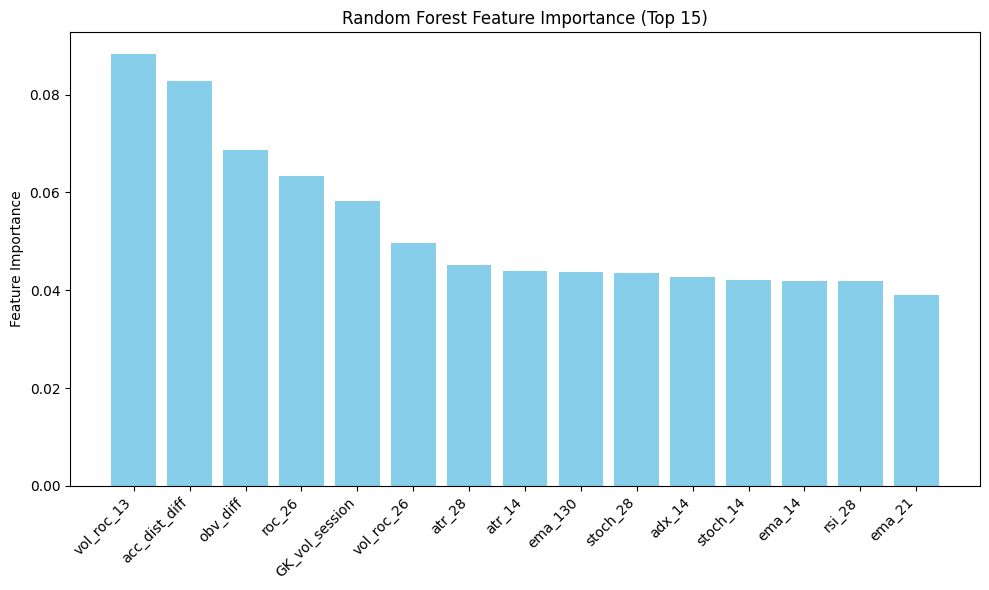

In [68]:
top_n = 15
top_features = importances.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), top_features.values, color='skyblue')
plt.xticks(range(top_n), top_features.index, rotation=45, ha='right')
plt.ylabel("Feature Importance")
plt.title(f"Random Forest Feature Importance (Top {top_n})")
plt.tight_layout()
plt.show()